# Proyecto de Análisis y Modelado de Ventas
---

# 1. Resumen Ejecutivo
- Problema de negocio abordado
Identificar los factores que afectan las ventas y ganancias de productos para optimizar decisiones de marketing, stock y promociones.

- Metodología utilizada\
Exploración de datos (EDA), modelos de regresión y clasificación (Random Forest Regressor y Regresión Logística) y segmentación de productos mediante K-Means.

- Principales hallazgos\
  La categoría Technology y la región West generan más ventas.
  Ventas y descuentos son las variables más influyentes en la predicción de ganancias.

  Eliminación de outliers mejoró ligeramente el desempeño del Random Forest Regressor (R² = 0,77).

  El modelo de clasificación alcanzó una precisión del 95 %.
  Segmentación identificó grupos de productos con alto profit, bajo profit y casos atípicos.

- Impacto esperado en el negocio\
  Optimizar stock y estrategias de marketing según los grupos de productos.

  Detectar productos que necesitan revisión de precios o promociones.

  Tomar decisiones más informadas para mejorar la rentabilidad.

# 2. Configuración  del entorno

# 2.1. Importar librerías

In [14]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#modelo random forest regresión
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Modelo random forest clasificación
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Modelos de regresión logística
from sklearn.linear_model import LogisticRegression

## Convertir categóricas a dummies y escalar)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

#división de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

#2.2. Conexión a drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

---

La empresa busca optimizar sus ventas y rentabilidad mediante un análisis de datos históricos de ventas, categorías de productos y comportamiento de los clientes. Entender qué factores influyen en las ventas y el profit permitirá tomar decisiones más informadas sobre inventario, promociones y segmentación de clientes.



---

### 3.2 Problema a Resolver

---

Actualmente, la empresa no cuenta con modelos predictivos ni segmentaciones claras para anticipar ventas o identificar clientes de alto valor. Esto dificulta planificar estrategias comerciales y optimizar recursos, afectando directamente la rentabilidad y eficiencia de las operaciones.

---

### 3.3 Objetivos del Proyecto

---

1. Predecir ventas y profit utilizando modelos de regresión (Random Forest Regressor).

2. Clasificar clientes en altos y bajos compradores mediante regresión logística, para mejorar estrategias de marketing y fidelización.

3. Segmentar clientes en grupos según comportamiento de compra (KMeans), identificando patrones que permitan acciones personalizadas y aumento de rentabilidad.

4. Extraer insights clave sobre las variables que más impactan ventas y profit, como categoría de producto, región y tipo de cliente.

---

### 3.4 Tipo de Problema de Machine Learning

Este proyecto combina tres tipos de problemas de Machine Learning:

1. Regresión: Predecir valores continuos como ventas y profit usando Random Forest Regressor.

2. Clasificación: Predecir si un cliente tiene alto o bajo nivel de compras mediante Regresión Logística.

3. Segmentación (Clustering): Agrupar clientes en segmentos según comportamiento de compra con KMeans, para identificar patrones y oportunidades de negocio.

# 4. Carga y exploración de datos

## 4.1. Carga de datos

In [4]:
file_path = '/content/drive/My Drive/Colab Notebooks/Superstore.xlsx'
df = pd.read_excel(file_path)

## 4.2. Descripción del dataset

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 4.3. Exploración Inicial de Datos (EDA)

In [ ]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n Primeras 5 filas:")
display(df.head())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

 Primeras 5 filas:


,Order Date,Ship Date,Ship Mode,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,11/8/2016,11/11/2016,Second Class,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,731.9400,3,0.00,219.5820
2,6/12/2016,6/16/2016,Second Class,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,957.5775,5,0.45,-383.0310
4,10/11/2015,10/18/2015,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,22.3680,2,0.20,2.5164



📈 Estadísticas Descriptivas:


,Sales,Quantity,Discount,Profit
count,9993.000000,9993.000000,9993.000000,9993.000000
mean,229.852846,3.789753,0.156188,28.660971
std,623.276074,2.225149,0.206457,234.271476
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.731000
50%,54.480000,3.000000,0.200000,8.671000
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES, DUPLICADO Y LIMPIEZA DE VARIABLES
# =====================================================

df.isnull().sum()

# si hubiera datos faltantes eliminarlos
# df = df.dropna()

df.duplicated().sum()
df = df.drop_duplicates()

# limpieza de variables que no sirven para el modelo
df=df.drop(['Row ID','Order ID','Customer ID','Customer Name','Product Name','Postal Code'],axis=1)


df.info()  # corroborando eliminación de variables

In [ ]:
# Convertir fechas
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df = df.drop(columns=['Ship Date'])

#5. Evaluación de Kpis

#5.1. KPIs principales

In [ ]:
kpis = pd.DataFrame({
    "Metric": ["Total Sales", "Total Profit", "Total Orders", "Average Ticket"],
    "Value": [
        f"${total_sales:,.2f}",
        f"${total_profit:,.2f}",
        total_orders,
        f"${avg_ticket:,.2f}"
    ]
})

kpis

,Metric,Value
0,Total Sales,"$2,296,919.49"
1,Total Profit,"$286,409.08"
2,Total Orders,9993
3,Average Ticket,$229.85


#5.2. Ventas por categoría y región

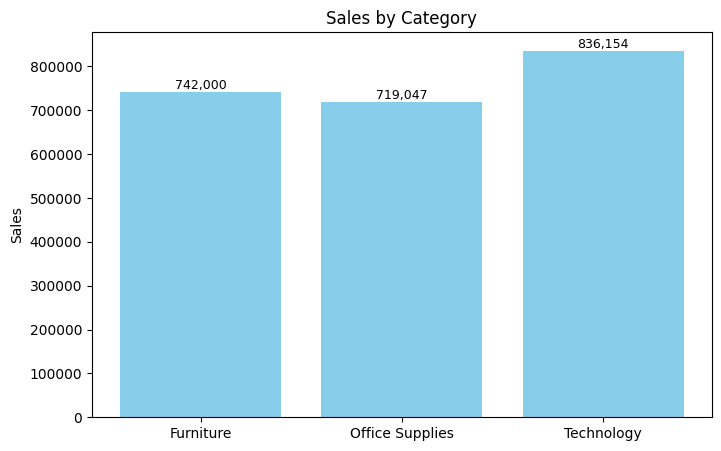

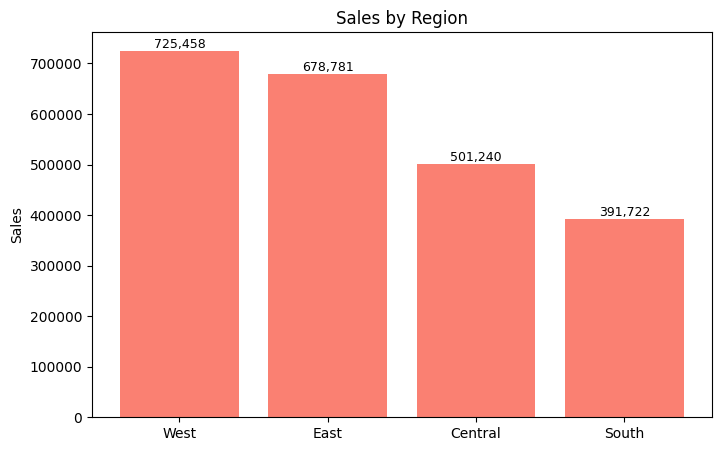

In [36]:
import matplotlib.pyplot as plt

# --- Sales by Category ---
sales_category = df.groupby('Category')['Sales'].sum().round(2)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(sales_category.index, sales_category.values, color='skyblue')

# Etiquetas encima de las barras
for i, v in enumerate(sales_category.values):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)

ax.set_title('Sales by Category')
ax.set_ylabel('Sales')
plt.show()

# --- Sales by Region ---
sales_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(sales_region.index, sales_region.values, color='salmon')

# Etiquetas encima de las barras
for i, v in enumerate(sales_region.values):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)

ax.set_title('Sales by Region')
ax.set_ylabel('Sales')
plt.show()

#5.3. Profit por categoría y región

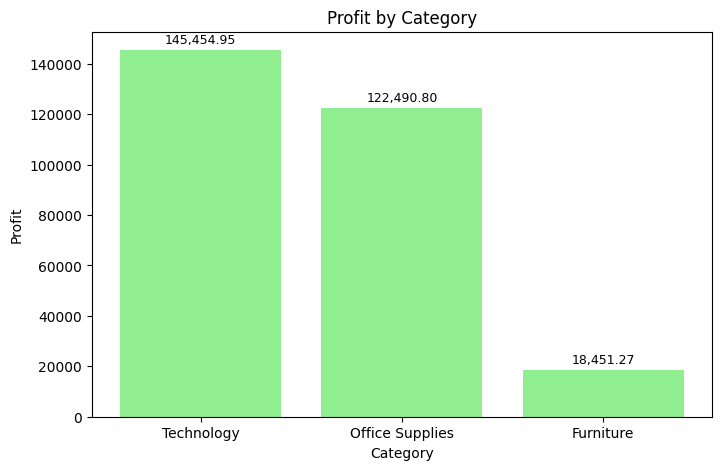

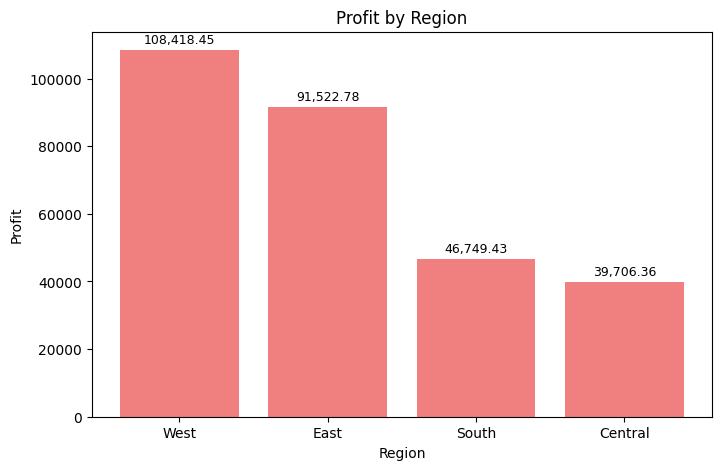

In [37]:
import matplotlib.pyplot as plt

# --- Profit by Category ---
profit_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(profit_category.index, profit_category.values, color='lightgreen')

# Etiquetas encima de las barras
for i, v in enumerate(profit_category.values):
    ax.text(i, v + 0.01*max(profit_category.values), f'{v:,.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Profit by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Profit')
plt.show()

# --- Profit by Region ---
profit_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(profit_region.index, profit_region.values, color='lightcoral')

# Etiquetas encima de las barras
for i, v in enumerate(profit_region.values):
    ax.text(i, v + 0.01*max(profit_region.values), f'{v:,.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Profit by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Profit')
plt.show()

#5.4. Top 10 productos por ventas

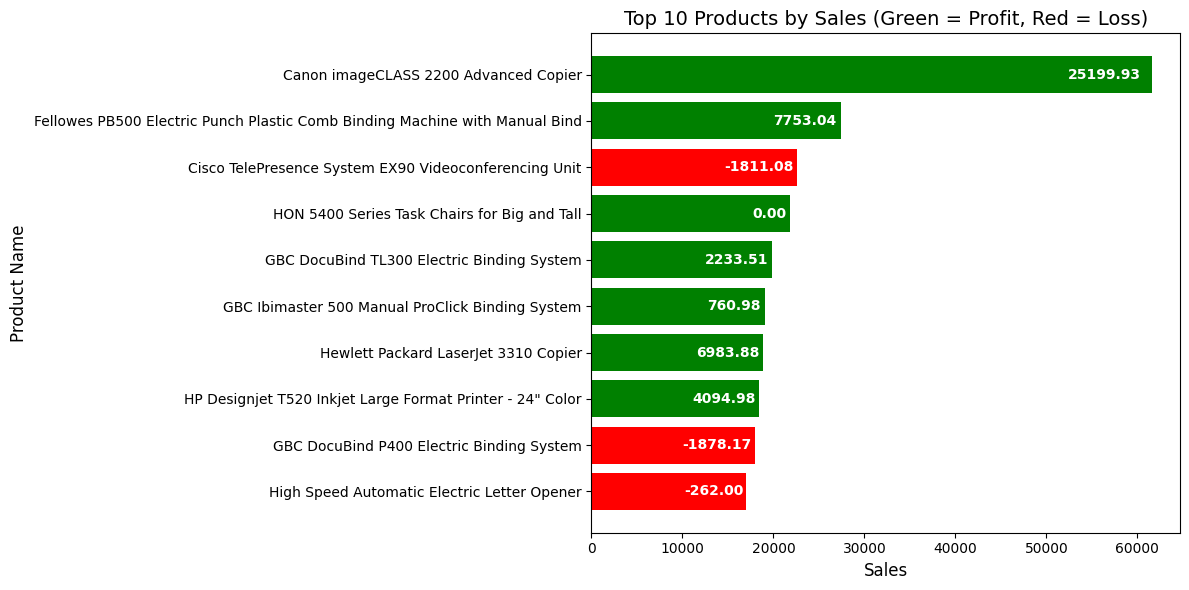

In [47]:
# Top 10 productos por ventas
product_summary = df.groupby('Product Name')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)
top_products = product_summary.head(10)

# Definir color según ganancia
colors = ['green' if x >= 0 else 'red' for x in top_products['Profit']]

# Gráfico de barras horizontal
plt.figure(figsize=(12,6))
bars = plt.barh(top_products.index, top_products['Sales'], color=colors)

# Agregar etiquetas dentro o fuera de la barra según espacio
for bar, profit in zip(bars, top_products['Profit']):
    width = bar.get_width()
    label = f"{profit:.2f}"

    if width > profit:  # si la barra es suficientemente larga, poner dentro
        plt.text(width - (0.02*width), bar.get_y() + bar.get_height()/2,
                 label, ha='right', va='center', fontsize=10, fontweight='bold', color='white')
    else:  # si la barra es muy corta, poner afuera
        plt.text(width + (0.01*width), bar.get_y() + bar.get_height()/2,
                 label, ha='left', va='center', fontsize=10, fontweight='bold', color='black')

plt.title('Top 10 Products by Sales (Green = Profit, Red = Loss)', fontsize=14)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.gca().invert_yaxis()  # Top 1 arriba
plt.grid(False)
plt.tight_layout()
plt.show()

# 5.5. Estacionalidad – Ventas por mes

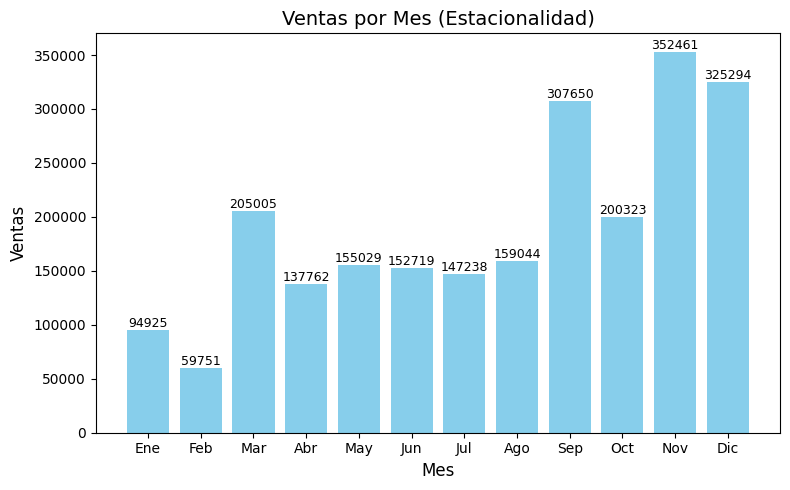

In [43]:
# Analizando estacionalidad
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month

# Ventas por mes
sales_month = df.groupby('Month')['Sales'].sum().round(0)  # redondeo a 0 decimales

# Gráfico de barras
plt.figure(figsize=(8,5))
bars = plt.bar(sales_month.index, sales_month.values, color='skyblue')

# Etiquetas encima de cada barra
for bar in bars:
    yval = int(bar.get_height())
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval}", ha='center', va='bottom', fontsize=9)

# Etiquetas y título
plt.title("Ventas por Mes (Estacionalidad)", fontsize=14)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Ventas", fontsize=12)
plt.xticks(ticks=sales_month.index, labels=[
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
])
plt.grid(False)  # Quitar cuadrícula interna
plt.tight_layout()
plt.show()

# 6. Modelos Predictivos / Diseño y Arquitectura del Modelo

### 6.1 RANDON FOREST REGRESOR (Predicción de Ventas/Profit)

6.1.1 Diseño del modelo

In [50]:
# Target
y = df['Profit']

# Variables predictoras
X = df[['Category', 'Sub-Category', 'Segment', 'State', 'Region', 'Ship Mode', 'Sales', 'Quantity', 'Discount']]

# Separar datos en train y validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertir variables categóricas a dummies y escalar numéricas
categorical_features = ['Category', 'Sub-Category', 'Segment', 'State', 'Region', 'Ship Mode']
numeric_features = ['Sales', 'Quantity', 'Discount']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# Entrenar el modelo (Random Forest Regressor)
categorical_features = ['Category', 'Sub-Category', 'Segment', 'State', 'Region', 'Ship Mode']
numeric_features = ['Sales', 'Quantity', 'Discount']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

#Compilar
model = RandomForestRegressor(random_state=42)
model.fit(X_train_processed, y_train)

# Predicciones
y_pred = model.predict(X_val_processed)

# Evaluación
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 52001.49
R^2 Score: -0.07


  6.1.2 Mejoramiento del modelo

In [26]:
# -------------------------------
# 1 Seleccionar features importantes
# -------------------------------
features = ['Category', 'Sales', 'Quantity', 'Discount']
target = 'Profit'

X = df[features]
y = df[target]

# -------------------------------
# 2 Filtrar outliers en Profit
#    - Mantener valores entre percentil 1 y 99
# -------------------------------
lower = y.quantile(0.01)
upper = y.quantile(0.99)

mask = (y >= lower) & (y <= upper)
X = X[mask]
y = y[mask]

# -------------------------------
# 3 Separar train y validation
# -------------------------------
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 4 Preprocesamiento: dummies + escalado
# -------------------------------
categorical_features = ['Category']
numeric_features = ['Sales', 'Quantity', 'Discount']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# -------------------------------
# 5️⃣ Entrenar Random Forest ajustado
# -------------------------------
model = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)
model.fit(X_train_processed, y_train)

# -------------------------------
# 6️⃣ Predicciones y evaluación
# -------------------------------
y_pred = model.predict(X_val_processed)

mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

# -------------------------------
# 7️⃣ Comparar algunas predicciones vs reales
# -------------------------------
comparison = pd.DataFrame({'Actual Profit': y_val, 'Predicted Profit': y_pred})
display(comparison.head(10))

Mean Squared Error: 1226.97
R^2 Score: 0.77


,Actual Profit,Predicted Profit
5915,8.8784,18.388869
7151,-135.0870,-124.283025
6556,-14.7594,-17.003055
2194,12.2850,12.786279
6058,17.4720,15.255182
7481,5.7510,4.336125
6517,41.7060,34.343570
2012,4.6344,11.465606
8818,18.6624,16.214668
7589,12.8744,24.587667


6.1.3. Cross validation

In [10]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_processed, y_train, cv=5, scoring='r2')

print("Cross Validation R² scores:", scores)
print("Average R²:", scores.mean())

Cross Validation R² scores: [0.69202666 0.74375071 0.71901047 0.76163773 0.71714913]
Average R²: 0.7267149413859096


# 6.2. Randon Forest classifier

In [12]:
# Clasificación de Profit positivo o negativo

# -------------------------------
# 1 Crear variable objetivo
# -------------------------------
df['Profit_Class'] = (df['Profit'] > 0).astype(int)

# Variables predictoras
features = ['Category', 'Sales', 'Quantity', 'Discount']
X = df[features]
y = df['Profit_Class']

# -------------------------------
# 2 Train / Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 3 Preprocesamiento
# -------------------------------
categorical_features = ['Category']
numeric_features = ['Sales', 'Quantity', 'Discount']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# -------------------------------
# 4 Entrenar modelo
# -------------------------------
clf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)

clf.fit(X_train_processed, y_train)

# -------------------------------
# 5 Predicciones
# -------------------------------
y_pred = clf.predict(X_test_processed)

# -------------------------------
# 6 Evaluación
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.95

Confusion Matrix:
[[ 280   97]
 [  10 1612]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84       377
           1       0.94      0.99      0.97      1622

    accuracy                           0.95      1999
   macro avg       0.95      0.87      0.90      1999
weighted avg       0.95      0.95      0.94      1999



#6.3. Logistic Regression

In [15]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_processed, y_train)

# Predicciones
y_pred_log = log_model.predict(X_test_processed)

# Evaluación
accuracy_log = accuracy_score(y_test, y_pred_log)

print(f"Logistic Regression Accuracy: {accuracy_log:.2f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.94

Confusion Matrix:
[[ 268  109]
 [   4 1618]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.71      0.83       377
           1       0.94      1.00      0.97      1622

    accuracy                           0.94      1999
   macro avg       0.96      0.85      0.90      1999
weighted avg       0.95      0.94      0.94      1999



# 7.4. Segmentación (Agrupamiento de Clientes / Productos)

,Sales,Profit,Cluster
0,261.9600,41.9136,0
1,731.9400,219.5820,0
2,14.6200,6.8714,0
3,957.5775,-383.0310,0
4,22.3680,2.5164,0


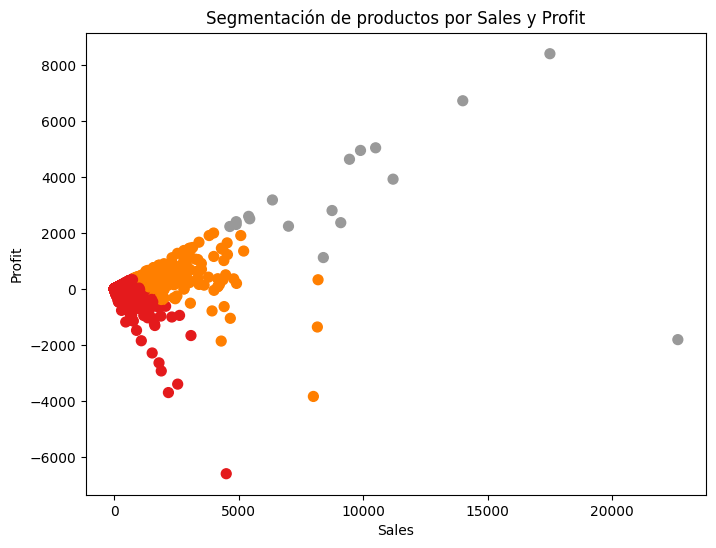

In [29]:
# -------------------------------
# Segmentación de productos con K-Means
# -------------------------------

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Seleccionamos las variables para segmentar
X = df[['Sales', 'Profit']]

# Escalamos las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Definimos número de clusters (puedes ajustar entre 3-5)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Agregamos los clusters al dataframe
df['Cluster'] = clusters

# Mostramos algunos datos con los clusters
display(df[['Sales', 'Profit', 'Cluster']].head())

print("\n")
# Gráfico de dispersión de los clusters
plt.figure(figsize=(8,6))
plt.scatter(df['Sales'], df['Profit'], c=df['Cluster'], cmap='Set1', s=50)
plt.title('Segmentación de productos por Sales y Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

# 7. Comparación de modelos

In [16]:
print("Model Comparison")

print(f"Random Forest Accuracy: {accuracy:.2f}")
print(f"Logistic Regression Accuracy: {accuracy_log:.2f}")

Model Comparison
Random Forest Accuracy: 0.95
Logistic Regression Accuracy: 0.94


In [25]:
# =====================================================
# Importancia de variables (Random Forest)
# =====================================================

importances = model.feature_importances_

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df['Importance'] = importance_df['Importance'].round(2)

display(importance_df)


,Feature,Importance
3,num__Sales,0.60
5,num__Discount,0.30
4,num__Quantity,0.05
0,cat__Category_Furniture,0.02
2,cat__Category_Technology,0.02
1,cat__Category_Office Supplies,0.01


#8. Insights

- Se identifican productos con altos volúmenes de venta en cantidad que, a pesar de su rotación, generan pérdidas para la empresa. Esto podría indicar precios insuficientes, descuentos elevados o altos costos asociados a estos productos.
- Un grupo reducido de productos concentra la mayor rentabilidad (Pareto)
- Algunos productos con alta venta generan pérdida. Se recomienda revisar su estrategia de precios o descuentos para mejorar rentabilidad.
- El cluster de productos con alto profit y ventas altas puede priorizarse para marketing y stock.
- El cluster con bajas ventas o pérdidas muestra productos que podrían requerir revisión de precios o promociones.
- La segmentación ayuda a la empresa a identificar grupos de productos o clientes con comportamientos similares, optimizando decisiones de marketing, stock y estrategias de venta


# 9. Conclusiones
---
- La categoría 'Technology' genera más ventas y profit.
- La región 'West' es la que más vende, seguida por 'East'.
- Los productos de menor precio tienen alto volumen pero menor profit.
- Se observa estacionalidad en meses como noviembre y diciembre.
- Las ventas y los descuentos fueron las variables más influyentes en la predicción de las ganancias.
- La eliminación de outliers permitió mejorar ligeramente el desempeño del modelo Random Forest Regressor, obteniendo un R² de 0,77, lo que demuestra un buen rendimiento predictivo.
- También se construyó un modelo de clasificación para predecir si una transacción generaría ganancias o pérdidas, alcanzando una precisión del 95 %.
- Ambos modelos presentan un desempeño muy similar, con una ligera ventaja para Random Forest.
- Estos resultados pueden ayudar a las empresas a comprender mejor los factores que afectan la rentabilidad y a tomar decisiones más informadas.